<a href="https://colab.research.google.com/github/adarithanmayee26/CodeAlpha_credit-scoring-model-/blob/main/disease_prediction_from_medical_dataset_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/sample_data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


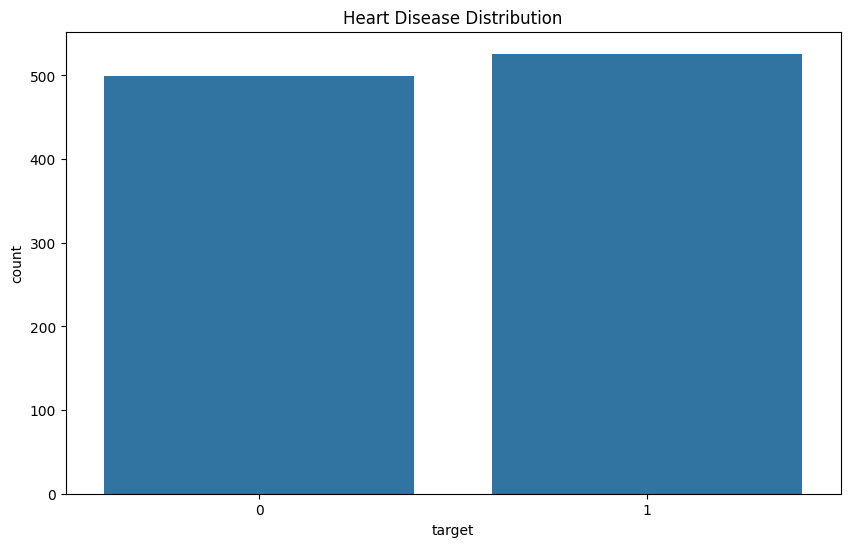

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

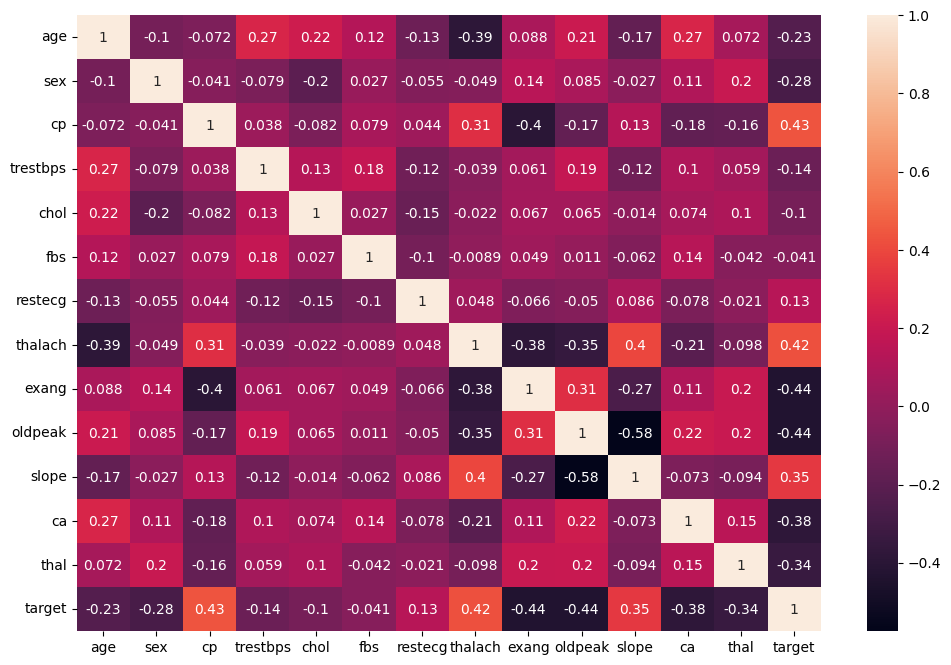

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [7]:
df['bp_age_ratio'] = df['trestbps'] / df['age']
df['chol_age_ratio'] = df['chol'] / df['age']

In [8]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [11]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [13]:
!pip install xgboost
from xgboost import XGBClassifier

xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [14]:
from sklearn.metrics import classification_report

models = {
    "Logistic": log_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       102
           1       0.77      0.86      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.80      0.80       205
weighted avg       0.80      0.80      0.80       205


SVM
              precision    recall  f1-score   support

           0       0.92      0.82      0.87       102
           1       0.84      0.93      0.88       103

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205


Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99 

In [15]:
from sklearn.metrics import roc_auc_score

for name, model in models.items():
    probs = model.predict_proba(X_test)[:,1]
    print(name, roc_auc_score(y_test, probs))

Logistic 0.875690081857986
SVM 0.9588806396344947
Random Forest 1.0
XGBoost 0.9860079954311822


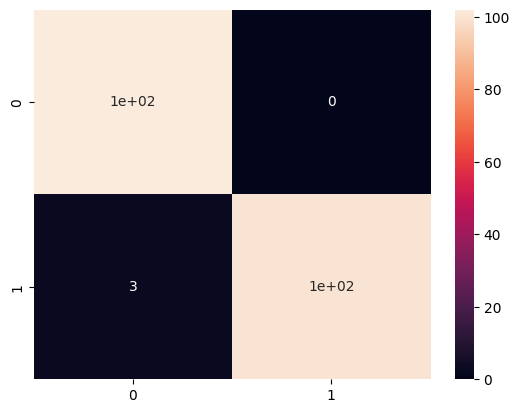

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_model.predict(X_test))
sns.heatmap(cm, annot=True)
plt.show()

In [18]:
import joblib

joblib.dump(rf_model, "heart_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("✅ Model and scaler saved successfully!")

✅ Model and scaler saved successfully!


In [19]:
!pip install gradio

In [20]:
import gradio as gr
import joblib
import random
import numpy as np

# Load model and scaler
model = joblib.load("heart_model.pkl")
scaler = joblib.load("scaler.pkl")

# Prediction function
def predict_heart(
    age, sex, cp, trestbps, chol, fbs,
    restecg, thalach, exang, oldpeak,
    slope, ca, thal
):

    # Feature engineering (same as training)
    bp_age_ratio = trestbps / age
    chol_age_ratio = chol / age

    data = [[
        age, sex, cp, trestbps, chol, fbs,
        restecg, thalach, exang, oldpeak,
        slope, ca, thal,
        bp_age_ratio, chol_age_ratio
    ]]

    data = scaler.transform(data)

    prediction = model.predict(data)[0]

    if prediction == 1:
        return "⚠️ Heart Disease Detected"
    else:
        return "✅ No Heart Disease"


# Random data generator
def random_values():
    return [
        random.randint(30, 70),  # age
        random.randint(0, 1),    # sex
        random.randint(0, 3),    # cp
        random.randint(90, 180), # trestbps
        random.randint(150, 300),# chol
        random.randint(0, 1),    # fbs
        random.randint(0, 2),    # restecg
        random.randint(90, 190), # thalach
        random.randint(0, 1),    # exang
        round(random.uniform(0.0, 5.0), 2), # oldpeak
        random.randint(0, 2),    # slope
        random.randint(0, 4),    # ca
        random.randint(0, 3)     # thal
    ]


# Gradio UI
with gr.Blocks() as app:
    gr.Markdown("## ❤️ Heart Disease Prediction System")

    with gr.Row():
        age = gr.Number(label="Age")
        sex = gr.Number(label="Sex (0 = Female, 1 = Male)")
        cp = gr.Number(label="Chest Pain Type")
        trestbps = gr.Number(label="Resting Blood Pressure")
        chol = gr.Number(label="Cholesterol")

    with gr.Row():
        fbs = gr.Number(label="Fasting Blood Sugar")
        restecg = gr.Number(label="Rest ECG")
        thalach = gr.Number(label="Max Heart Rate")
        exang = gr.Number(label="Exercise Angina")
        oldpeak = gr.Number(label="Oldpeak")

    with gr.Row():
        slope = gr.Number(label="Slope")
        ca = gr.Number(label="Number of Vessels")
        thal = gr.Number(label="Thalassemia")

    output = gr.Textbox(label="Prediction")

    # Buttons
    predict_btn = gr.Button("Predict")
    random_btn = gr.Button("Generate Random Values")

    predict_btn.click(
        predict_heart,
        inputs=[
            age, sex, cp, trestbps, chol,
            fbs, restecg, thalach, exang,
            oldpeak, slope, ca, thal
        ],
        outputs=output
    )

    random_btn.click(
        random_values,
        outputs=[
            age, sex, cp, trestbps, chol,
            fbs, restecg, thalach, exang,
            oldpeak, slope, ca, thal
        ]
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e082bd9a532f95857f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
